# 34 — Building a Transformer Encoder Block

The [previous notebooks](./32_multi_head_attention.ipynb) developed [multi-head attention](./32_multi_head_attention.ipynb) and [positional representations](./33_positional_encoding_and_transformer_inputs.ipynb). We now combine attention with layer normalization, residual connections, and a position-wise feed-forward network to form one Transformer encoder block.

## Learning objectives

- distinguish layer normalization from batch normalization;
- implement layer normalization over each token's features;
- implement a position-wise feed-forward network;
- explain the two residual paths in an encoder block;
- distinguish pre-norm and post-norm ordering;
- assemble and trace a complete pre-norm encoder forward pass.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from cs231n_practice.attention import multi_head_attention_forward

SEED = 42
generator = np.random.default_rng(SEED)
np.set_printoptions(precision=3, suppress=True)


## 1. Layer normalization

For an input $X$ with shape $(N,L,D)$, layer normalization calculates statistics across the final feature dimension. Every token vector $X_{n,l,:}$ gets its own mean and variance:

$$
\mu_{n,l}=\frac{1}{D}\sum_d X_{n,l,d},
$$

$$
\sigma^2_{n,l}=\frac{1}{D}\sum_d(X_{n,l,d}-\mu_{n,l})^2.
$$

The normalized and affine-transformed result is

$$
Y_{n,l,d}=\gamma_d\frac{X_{n,l,d}-\mu_{n,l}}{\sqrt{\sigma^2_{n,l}+\epsilon}}+\beta_d.
$$

$\gamma$ and $\beta$ contain one learned value per feature and broadcast across batches and positions. Unlike batch normalization, layer normalization does not combine examples and needs no running statistics or train/test behavior.

### Exercise 1 — Implement layer normalization


In [ ]:
def layernorm_forward(x, gamma, beta, epsilon=1e-5):
    """Normalize every token across its final feature dimension."""
    # calculate mean and variance along the final axis.
    mean = x.mean(axis=-1, keepdims=True)
    variance = x.var(axis=-1, keepdims=True)
    # Keep that axis so subtraction and division broadcast correctly.
    # normalize x, then apply gamma and beta.
    x_normalized = (x - mean) / np.sqrt(variance + epsilon)
    return gamma * x_normalized + beta

x = generator.normal(size=(3, 4, 8))
gamma = np.ones(8)
beta = np.zeros(8)
normalized = layernorm_forward(x, gamma, beta)

assert normalized.shape == x.shape
np.testing.assert_allclose(normalized.mean(axis=-1), 0.0, atol=1e-7)
np.testing.assert_allclose(normalized.var(axis=-1), 1.0, atol=2e-4)


## 2. Every token is normalized independently

Layer normalization uses only the $D$ features inside one token vector. Changing another example or another sequence position must not change the normalized result for the token we are observing. This makes its behavior independent of batch size and suitable for variable-length sequence processing.

### Exercise 2 — Verify token independence


In [24]:
changed_x = x.copy()
# make a large change to every token except x[0, 0].
# Apply a non-uniform feature change to every token.
feature_change = np.linspace(-10.0, 10.0, x.shape[-1])
changed_x += feature_change
# Restore the one token being observed.
changed_x[0, 0] = x[0, 0]

changed_normalized = layernorm_forward(changed_x, gamma, beta)

# The untouched token must produce exactly the same normalized vector.
np.testing.assert_allclose(changed_normalized[0, 0], normalized[0, 0])
# At least one changed token should produce a different result.
assert not np.allclose(changed_normalized[1, 1], normalized[1, 1])


## 3. Position-wise feed-forward network

After attention mixes information **between positions**, a feed-forward network transforms the features **within each position**:

$$
FFN(X)=\mathrm{ReLU}(XW_1+b_1)W_2+b_2.
$$

The same weights are applied independently to every token. For model dimension $D$ and hidden dimension $D_{ff}$:

```text
X:        (N, L, D)
W1:       (D, D_ff)
hidden:   (N, L, D_ff)
W2:       (D_ff, D)
output:   (N, L, D)
```

Keeping the output width $D$ allows it to be added back through a residual connection.

### Exercise 3 — Implement the position-wise network


In [7]:
def feed_forward_forward(x, weights1, bias1, weights2, bias2):
    """Apply the same two-layer network independently to every token."""
    # affine -> ReLU -> affine.
    hidden = x @ weights1 + bias1
    hidden_relu = np.maximum(0.0, hidden)
    output = hidden_relu @ weights2 + bias2
    return output


model_dim = 8
feed_forward_dim = 24
weights1 = generator.normal(scale=0.1, size=(model_dim, feed_forward_dim))
bias1 = np.zeros(feed_forward_dim)
weights2 = generator.normal(scale=0.1, size=(feed_forward_dim, model_dim))
bias2 = np.zeros(model_dim)

feed_forward_output = feed_forward_forward(
    normalized, weights1, bias1, weights2, bias2
)
assert feed_forward_output.shape == normalized.shape
np.testing.assert_allclose(
    feed_forward_output[0, 0],
    np.maximum(0.0, normalized[0, 0] @ weights1 + bias1) @ weights2 + bias2,
)


## 4. Two residual paths

An encoder block contains two main sublayers: multi-head self-attention and the feed-forward network. Each sublayer is wrapped by a residual connection:

```text
x ----------------------+
  -> attention branch --+-> after_attention

after_attention --------+
  -> feed-forward branch +-> block_output
```

A residual path preserves the original representation while the branch learns a change to it. It also supplies an identity gradient route: if $Y=X+F(X)$, then backward propagation contains a direct contribution $dX=dY$ in addition to the gradient through $F$.

### Exercise 4 — Verify residual behavior


In [ ]:
def residual_add(x, branch_output):
    """Add a same-shaped sublayer result to its input."""
    # validate equal shapes and return the residual sum.
    assert x.shape == branch_output.shape, "Input and branch output must have the same shape."
    return x + branch_output


zero_branch = np.zeros_like(x)
identity_output = residual_add(x, zero_branch)
np.testing.assert_array_equal(identity_output, x)

with_update = residual_add(x, 0.1 * np.ones_like(x))
np.testing.assert_allclose(with_update - x, 0.1)


## 5. Pre-norm versus post-norm

Normalization and residual addition can be ordered in two common ways. For a sublayer $F$:

**Post-norm** (used by the original Transformer):

$$
Y=\mathrm{LayerNorm}(X+F(X)).
$$

**Pre-norm** (common in modern deep Transformers):

$$
Y=X+F(\mathrm{LayerNorm}(X)).
$$

In pre-norm, the residual stream has a direct identity path from $X$ to $Y$. This generally makes optimization of deep stacks easier. The two arrangements are not algebraically equivalent and can learn different functions. This notebook uses pre-norm.

### Exercise 5 — Compare the two orderings


In [10]:
toy_x = generator.normal(size=(2, 3, model_dim))
toy_branch_f = lambda x: 0.2 * x

# calculate post_norm = LayerNorm(toy_x + toy_branch).
post_norm = layernorm_forward(toy_x + toy_branch_f(toy_x), gamma, beta)
# calculate pre_norm = toy_x + 0.2 * LayerNorm(toy_x).
pre_norm = toy_x + toy_branch_f(layernorm_forward(toy_x, gamma, beta))

assert post_norm.shape == toy_x.shape
assert pre_norm.shape == toy_x.shape
assert not np.allclose(pre_norm, post_norm)


## 6. Complete pre-norm encoder block

One pre-norm encoder block follows this sequence:

```text
normalized_for_attention = LayerNorm(x)
attention_update = MultiHeadSelfAttention(normalized_for_attention)
after_attention = x + attention_update
normalized_for_ffn = LayerNorm(after_attention)
feed_forward_update = FFN(normalized_for_ffn)
output = after_attention + feed_forward_update
```

Both branch outputs must have shape $(N,L,D)$ so their residual additions are valid. Positional information is normally added before the first encoder block rather than separately inside every block.

### Exercise 6 — Assemble the encoder block


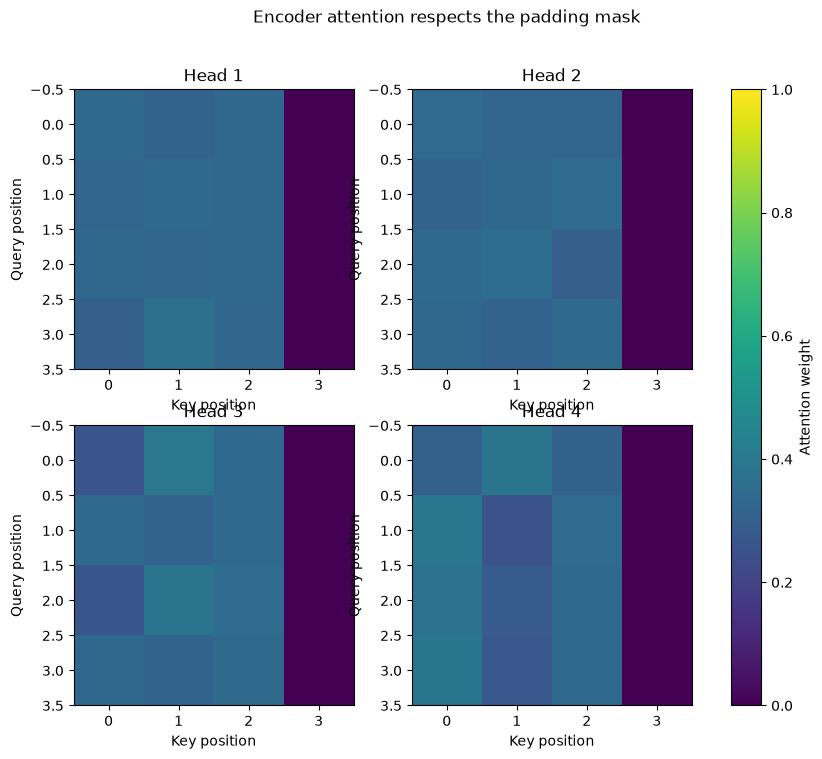

In [22]:
def transformer_encoder_block_forward(x, parameters, num_heads, mask=None):
    """Calculate one pre-norm Transformer encoder block."""
    # unpack the normalization, attention, and FFN parameters.
    gamma1 = parameters["gamma1"]
    beta1 = parameters["beta1"]
    W_query = parameters["W_query"]
    W_key = parameters["W_key"]
    W_value = parameters["W_value"]
    W_output = parameters["W_output"]
    b_query = parameters["b_query"]
    b_key = parameters["b_key"]
    b_value = parameters["b_value"]
    b_output = parameters["b_output"]
    gamma2 = parameters["gamma2"]
    beta2 = parameters["beta2"]
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    # normalize, run self-attention, and make the first residual sum.
    normalized = layernorm_forward(x, gamma1, beta1)
    attention_output, attention_weights, attention_cache = multi_head_attention_forward(
        normalized,
        normalized,
        normalized,
        W_query,
        W_key,
        W_value,
        W_output,
        b_query,
        b_key,
        b_value,
        b_output,
        num_heads=num_heads,
        mask=mask,
    )
    residual1 = residual_add(x, attention_output)
    # normalize again, run the FFN, and make the second residual sum.
    normalized2 = layernorm_forward(residual1, gamma2, beta2)
    ffn_output = feed_forward_forward(normalized2, W1, b1, W2, b2)
    residual2 = residual_add(residual1, ffn_output) 
    # Return both the block output and attention weights.
    return residual2, attention_weights


num_heads = 4
parameters = {
    "gamma1": np.ones(model_dim),
    "beta1": np.zeros(model_dim),
    "W_query": generator.normal(scale=0.1, size=(model_dim, model_dim)),
    "W_key": generator.normal(scale=0.1, size=(model_dim, model_dim)),
    "W_value": generator.normal(scale=0.1, size=(model_dim, model_dim)),
    "W_output": generator.normal(scale=0.1, size=(model_dim, model_dim)),
    "b_query": np.zeros(model_dim),
    "b_key": np.zeros(model_dim),
    "b_value": np.zeros(model_dim),
    "b_output": np.zeros(model_dim),
    "gamma2": np.ones(model_dim),
    "beta2": np.zeros(model_dim),
    "W1": weights1,
    "b1": bias1,
    "W2": weights2,
    "b2": bias2,
}
valid_tokens = np.array([
    [True, True, True, True],
    [True, True, True, False],
    [True, True, False, False],
])
padding_mask = valid_tokens[:, None, None, :]
block_output, attention_weights = transformer_encoder_block_forward(
    x, parameters, num_heads=num_heads, mask=padding_mask
)

assert block_output.shape == x.shape
assert attention_weights.shape == (3, num_heads, 4, 4)
np.testing.assert_allclose(attention_weights.sum(axis=-1), 1.0)
np.testing.assert_array_equal(
    attention_weights[~np.broadcast_to(padding_mask, attention_weights.shape)],
    0.0,
)

fig, axes = plt.subplots(2, num_heads//2, figsize=(10, 8))
for head_index, axis in enumerate(axes.ravel()):
    image = axis.imshow(attention_weights[1, head_index], vmin=0, vmax=1)
    axis.set_title(f"Head {head_index + 1}")
    axis.set_xlabel("Key position")
    axis.set_ylabel("Query position")
fig.colorbar(image, ax=axes, label="Attention weight")
fig.suptitle("Encoder attention respects the padding mask")
plt.show()


## Reflection

Answer briefly in your own words.

1. Across which axis does layer normalization calculate statistics for $(N,L,D)$ input?
2. Why does layer normalization need no running mean or variance?
3. What different roles do self-attention and the feed-forward network play?
4. Why must each sublayer return the model dimension $D$?
5. What is the difference between pre-norm and post-norm?
6. Where is positional information added relative to an encoder stack?

### Answers

1. Only across D. Layer normalization calculates a separate mean and variance across the final feature dimension \(D\) for every (batch, position) pair.
2. cause it depends only on one particular sample data at specific step. It uses statistics from each individual token vector rather than statistics collected across a batch. Therefore, it behaves the same during training and inference and needs no running statistics.
3. self-attention learn token dependencies and positional details, feed-forward combines those details. Self-attention mixes information between sequence positions. The feed-forward network independently transforms the features within each resulting position using shared weights.
4. to allow residual path. Each sublayer must return width \(D\) so that its output has the same shape as the residual stream and can be added to it.
5. pre-norm normalize x before passing to attention block, post-norm normalize sum of residual block and f(x). Pre-norm normalizes before applying the sublayer:
$
Y=X+F(\mathrm{LayerNorm}(X)).
$
Post-norm normalizes after the residual addition:
$
Y=\mathrm{LayerNorm}(X+F(X)).
$
6. Positional information is added to token embeddings before entering the encoder stack. Every encoder block then processes representations that already contain positional information.
